# EDA: Merged Tracking and Event Data

This notebook explores the 376 successfully merged matches between SkillCorner tracking data and StatsBomb event data.

## Objectives
1. Understand the structure of merged data
2. Validate synchronization quality
3. Analyze match coverage and completeness
4. Identify patterns and potential issues

In [1]:
import pandas as pd
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Match Mapping and Identify Successful Merges

In [2]:
# Load the match mapping
mapping_df = pd.read_csv('data/mapping_ids/skc_sb_match_mapping.csv')
print(f"Total mapped matches: {len(mapping_df)}")
print(f"\nMapping columns: {mapping_df.columns.tolist()}")
print(f"\nFirst few mappings:")
mapping_df.head()

Total mapped matches: 380

Mapping columns: ['skc_match_id', 'sb_match_id', 'sb_home_team_id', 'date', 'home_team', 'away_team']

First few mappings:


,skc_match_id,sb_match_id,sb_home_team_id,date,home_team,away_team
0,1410827,3925227,1884,2024-02-23,Nagoya Grampus,Kashima Antlers
1,1410828,3925226,1889,2024-02-23,Sanfrecce Hiroshima,Urawa Red Diamonds
2,1411836,3925231,1895,2024-02-24,Shonan Bellmare,Kawasaki Frontale
3,1411839,3925233,1894,2024-02-24,Sagan Tosu,Albirex Niigata
4,1411840,3925230,4652,2024-02-24,Jubilo Iwata,Vissel Kobe


In [3]:
# Identify successfully processed matches
output_dir = Path('data/merged_data')

successful_matches = []
failed_matches = []

for idx, row in mapping_df.iterrows():
    skc_match_id = row['skc_match_id']
    match_dir = output_dir / str(skc_match_id)
    
    # Check if synchronization was successful
    if (match_dir / 'freeze_frame_format.json').exists():
        successful_matches.append({
            'skc_match_id': skc_match_id,
            'sb_match_id': row['sb_match_id'],
            'sb_home_team_id': row['sb_home_team_id'],
            'match_dir': match_dir
        })
    else:
        failed_matches.append(skc_match_id)

print(f"\n{'='*70}")
print(f"SYNCHRONIZATION STATUS")
print(f"{'='*70}")
print(f"✓ Successful: {len(successful_matches)}/{len(mapping_df)} ({len(successful_matches)/len(mapping_df)*100:.1f}%)")
print(f"✗ Failed: {len(failed_matches)}/{len(mapping_df)} ({len(failed_matches)/len(mapping_df)*100:.1f}%)")

if failed_matches:
    print(f"\nFailed match IDs: {failed_matches}")

# Convert to DataFrame for easier analysis
successful_df = pd.DataFrame(successful_matches)
print(f"\n✓ Created DataFrame with {len(successful_df)} successful matches")


SYNCHRONIZATION STATUS
✓ Successful: 376/380 (98.9%)
✗ Failed: 4/380 (1.1%)

Failed match IDs: [1900931, 1901682, 1901686, 1901687]

✓ Created DataFrame with 376 successful matches


## 2. Load and Analyze Synchronization Reports

In [4]:
# Load synchronization quality reports for all matches
all_reports = []

for idx, match in successful_df.iterrows():
    report_path = match['match_dir'] / 'report_by_event_type.csv'
    
    if report_path.exists():
        report = pd.read_csv(report_path)
        report['skc_match_id'] = match['skc_match_id']
        report['sb_match_id'] = match['sb_match_id']
        all_reports.append(report)

# Combine all reports
combined_reports = pd.concat(all_reports, ignore_index=True)

print(f"Loaded synchronization reports for {len(all_reports)} matches")
print(f"\nReport columns: {combined_reports.columns.tolist()}")
print(f"\nTotal rows in combined report: {len(combined_reports)}")
print(f"\nFirst few rows:")
combined_reports.head(10)

Loaded synchronization reports for 376 matches

Report columns: ['statsbomb_event_type', 'nb_events', 'is_matched', '%_is_matched', 'is_matched_is_player_detected', 'is_not_matched', 'is_not_matched_is_player_detected', 'is_not_matched_has_statsbomb_player_id_attached', 'is_not_matched_frame_tracking_data_available', 'is_matched_applicable', 'skc_match_id', 'sb_match_id']

Total rows in combined report: 10298

First few rows:


,statsbomb_event_type,nb_events,is_matched,%_is_matched,is_matched_is_player_detected,is_not_matched,is_not_matched_is_player_detected,is_not_matched_has_statsbomb_player_id_attached,is_not_matched_frame_tracking_data_available,is_matched_applicable,skc_match_id,sb_match_id
0,50/50,12,11,91.7,11,1,1,1,1,True,1410827,3925227
1,Ball Receipt*,974,844,86.7,832,130,103,130,116,True,1410827,3925227
2,Ball Recovery,107,99,92.5,97,8,7,8,8,True,1410827,3925227
3,Block,38,36,94.7,34,2,2,2,2,True,1410827,3925227
4,Carry,782,744,95.1,739,38,33,38,38,True,1410827,3925227
5,Clearance,73,51,69.9,49,22,21,22,22,True,1410827,3925227
6,Dispossessed,27,24,88.9,24,3,3,3,3,True,1410827,3925227
7,Dribble,14,13,92.9,12,1,1,1,1,True,1410827,3925227
8,Dribbled Past,7,7,100.0,6,0,0,0,0,True,1410827,3925227
9,Duel,85,73,85.9,68,12,10,12,12,True,1410827,3925227


In [5]:
# Summary statistics by event type
print("\n" + "="*70)
print("SYNCHRONIZATION QUALITY BY EVENT TYPE")
print("="*70)

# Group by event type and calculate summary statistics
event_summary = combined_reports.groupby('statsbomb_event_type').agg({
    'nb_events': 'sum',
    'is_matched': 'sum',
    '%_is_matched': 'mean'
}).round(2)

event_summary = event_summary.sort_values('nb_events', ascending=False)
event_summary['match_rate_%'] = event_summary['%_is_matched']

print(f"\nTop 20 event types by frequency:")
print(event_summary.head(20))


SYNCHRONIZATION QUALITY BY EVENT TYPE

Top 20 event types by frequency:
                      nb_events  is_matched  %_is_matched  match_rate_%
statsbomb_event_type                                                   
Pass                     353641      298444         84.16         84.16
Ball Receipt*            324928      270044         82.96         82.96
Carry                    268575      244894         91.10         91.10
Pressure                 108325       86985         80.36         80.36
Ball Recovery             35482       31729         89.48         89.48
Duel                      26382       21406         81.25         81.25
Clearance                 17451       12648         72.22         72.22
Block                     15388       13061         85.03         85.03
Goal Keeper               12446        6862         55.02         55.02
Foul Committed            10307        8631         83.70         83.70
Shot                       9942        7951         79.90      

In [6]:
# Overall synchronization statistics
total_events = combined_reports['nb_events'].sum()
total_matched = combined_reports['is_matched'].sum()
overall_match_rate = (total_matched / total_events * 100)

print("\n" + "="*70)
print("OVERALL SYNCHRONIZATION STATISTICS")
print("="*70)
print(f"Total events across all matches: {total_events:,}")
print(f"Successfully matched events: {total_matched:,}")
print(f"Overall match rate: {overall_match_rate:.2f}%")
print(f"\nEvents per match (average): {total_events/len(successful_df):.0f}")
print(f"Matched events per match (average): {total_matched/len(successful_df):.0f}")


OVERALL SYNCHRONIZATION STATISTICS
Total events across all matches: 1,244,341
Successfully matched events: 1,045,837
Overall match rate: 84.05%

Events per match (average): 3309
Matched events per match (average): 2781


## 3. Visualize Synchronization Quality

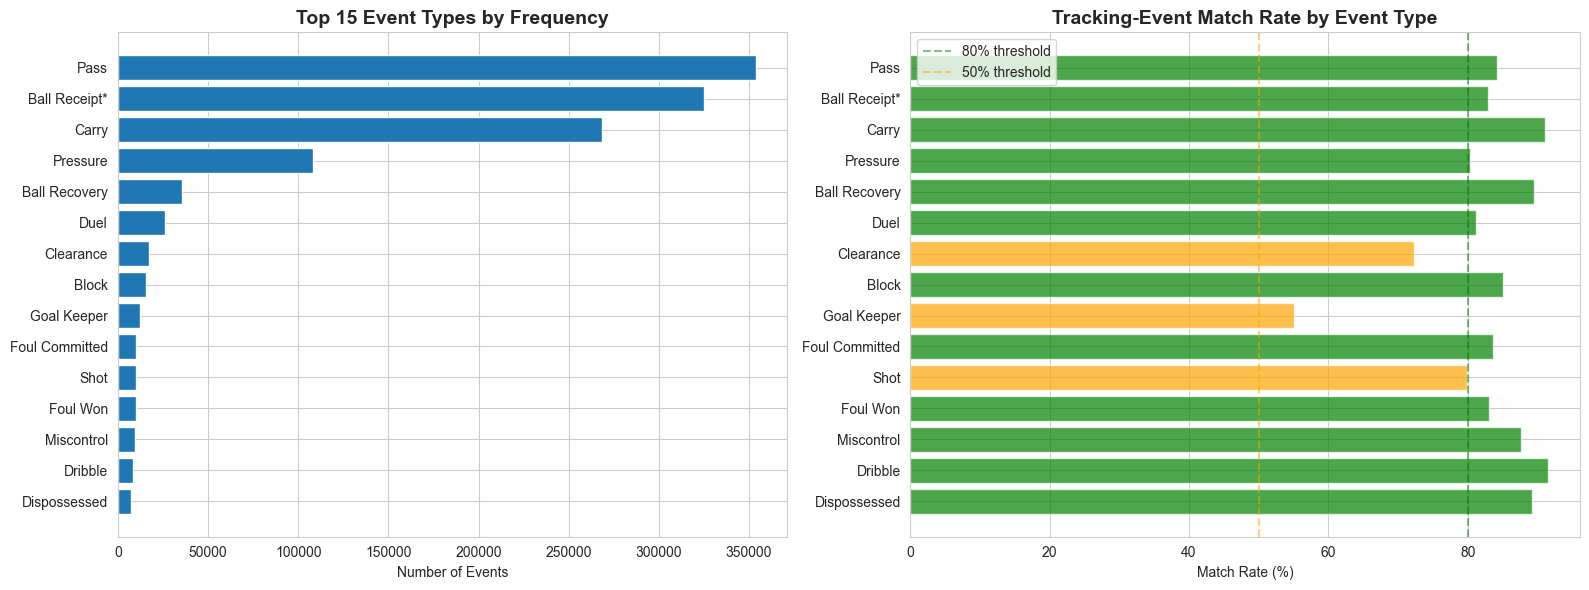


Color coding:
  Green: Good match rate (>80%)
  Orange: Moderate match rate (50-80%)
  Red: Low match rate (<50%)


In [7]:
# Plot match rate by event type (top 15)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 by frequency
top_events = event_summary.head(15)
ax1.barh(range(len(top_events)), top_events['nb_events'])
ax1.set_yticks(range(len(top_events)))
ax1.set_yticklabels(top_events.index)
ax1.set_xlabel('Number of Events')
ax1.set_title('Top 15 Event Types by Frequency', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Match rate for top 15
colors = ['green' if x >= 80 else 'orange' if x >= 50 else 'red' for x in top_events['match_rate_%']]
ax2.barh(range(len(top_events)), top_events['match_rate_%'], color=colors, alpha=0.7)
ax2.set_yticks(range(len(top_events)))
ax2.set_yticklabels(top_events.index)
ax2.set_xlabel('Match Rate (%)')
ax2.set_title('Tracking-Event Match Rate by Event Type', fontsize=14, fontweight='bold')
ax2.axvline(x=80, color='green', linestyle='--', alpha=0.5, label='80% threshold')
ax2.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
ax2.legend()
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\nColor coding:")
print("  Green: Good match rate (>80%)")
print("  Orange: Moderate match rate (50-80%)")
print("  Red: Low match rate (<50%)")

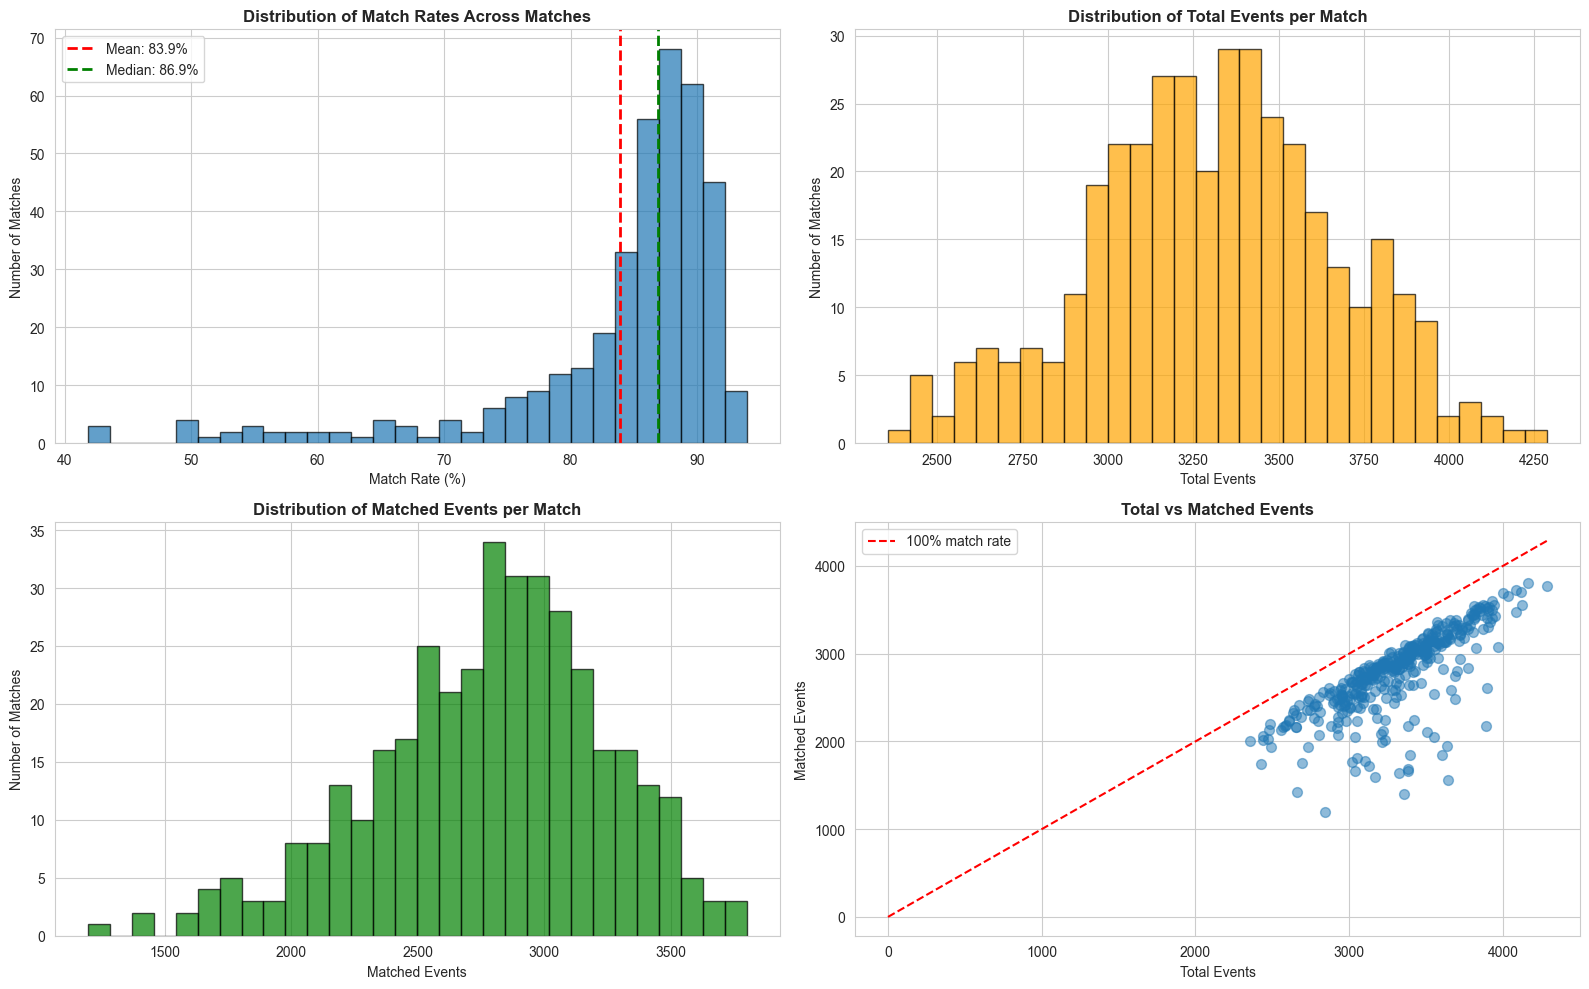


Match Quality Statistics:
       total_events  matched_events  match_rate
count    376.000000      376.000000  376.000000
mean    3309.417553     2781.481383   83.900892
std      361.495809      464.984679    9.313180
min     2355.000000     1196.000000   41.827925
25%     3070.500000     2504.500000   82.496591
50%     3320.000000     2834.500000   86.884715
75%     3554.250000     3100.000000   89.302692
max     4287.000000     3800.000000   93.928372


In [8]:
# Match quality distribution across matches
match_quality = []

for match_id in successful_df['skc_match_id'].unique():
    match_report = combined_reports[combined_reports['skc_match_id'] == match_id]
    total = match_report['nb_events'].sum()
    matched = match_report['is_matched'].sum()
    
    if total > 0:
        match_quality.append({
            'skc_match_id': match_id,
            'total_events': total,
            'matched_events': matched,
            'match_rate': (matched / total * 100)
        })

match_quality_df = pd.DataFrame(match_quality)

# Plot distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Match rate distribution
axes[0, 0].hist(match_quality_df['match_rate'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(match_quality_df['match_rate'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {match_quality_df['match_rate'].mean():.1f}%")
axes[0, 0].axvline(match_quality_df['match_rate'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f"Median: {match_quality_df['match_rate'].median():.1f}%")
axes[0, 0].set_xlabel('Match Rate (%)')
axes[0, 0].set_ylabel('Number of Matches')
axes[0, 0].set_title('Distribution of Match Rates Across Matches', fontweight='bold')
axes[0, 0].legend()

# Total events per match
axes[0, 1].hist(match_quality_df['total_events'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Total Events')
axes[0, 1].set_ylabel('Number of Matches')
axes[0, 1].set_title('Distribution of Total Events per Match', fontweight='bold')

# Matched events per match
axes[1, 0].hist(match_quality_df['matched_events'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Matched Events')
axes[1, 0].set_ylabel('Number of Matches')
axes[1, 0].set_title('Distribution of Matched Events per Match', fontweight='bold')

# Scatter: total vs matched events
axes[1, 1].scatter(match_quality_df['total_events'], match_quality_df['matched_events'], 
                   alpha=0.5, s=50)
# Add diagonal line (100% match rate)
max_val = match_quality_df['total_events'].max()
axes[1, 1].plot([0, max_val], [0, max_val], 'r--', label='100% match rate')
axes[1, 1].set_xlabel('Total Events')
axes[1, 1].set_ylabel('Matched Events')
axes[1, 1].set_title('Total vs Matched Events', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nMatch Quality Statistics:")
print(match_quality_df[['total_events', 'matched_events', 'match_rate']].describe())

## 4. Explore Sample Freeze Frame Data

In [9]:
# Load a sample freeze frame file to understand structure
sample_match = successful_df.iloc[0]
sample_freeze_frame_path = sample_match['match_dir'] / 'freeze_frame_format.json'

print(f"Loading sample freeze frame data from match: {sample_match['skc_match_id']}")
print(f"StatsBomb Match ID: {sample_match['sb_match_id']}")

with open(sample_freeze_frame_path, 'r') as f:
    sample_freeze_frame = json.load(f)

print(f"\nFreeze frame data structure:")
print(f"  Type: {type(sample_freeze_frame)}")

if isinstance(sample_freeze_frame, dict):
    print(f"  Top-level keys: {list(sample_freeze_frame.keys())}")
elif isinstance(sample_freeze_frame, list):
    print(f"  Number of events: {len(sample_freeze_frame)}")
    if len(sample_freeze_frame) > 0:
        print(f"\n  First event keys: {list(sample_freeze_frame[0].keys())}")
        print(f"\n  Sample event structure:")
        import pprint
        pprint.pprint(sample_freeze_frame[0], depth=3)

Loading sample freeze frame data from match: 1410827
StatsBomb Match ID: 3925227

Freeze frame data structure:
  Type: <class 'list'>
  Number of events: 3639

  First event keys: ['frame', 'timestamp', 'period', 'ball_data', 'possession', 'image_corners_projection', 'player_data', 'statsbomb_event_id', 'statsbomb_event_type', 'player_id', 'statsbomb_player_id', 'team_id', 'statsbomb_team_id', 'is_matched', 'is_player_detected', 'projected_statsbomb_event_x', 'projected_statsbomb_event_y']

  Sample event structure:
{'ball_data': {'is_detected': True, 'x': 0.08, 'y': -0.05, 'z': 0.21},
 'frame': 26,
 'image_corners_projection': {'x_bottom_left': -10.84,
                              'x_bottom_right': 10.69,
                              'x_top_left': -30.11,
                              'x_top_right': 31.3,
                              'y_bottom_left': -30.21,
                              'y_bottom_right': -29.8,
                              'y_top_left': 39.0,
                    


FREEZE FRAME DATA ANALYSIS (First 100 events)

Events with tracking data: 0/100
Events with freeze frame: 0/100
Events with location: 0/100

Event types with freeze frames:
Series([], Name: count, dtype: int64)

Average players per freeze frame: 0.0
Max players in a frame: 0


IndexError: index 0 is out of bounds for axis 0 with size 0

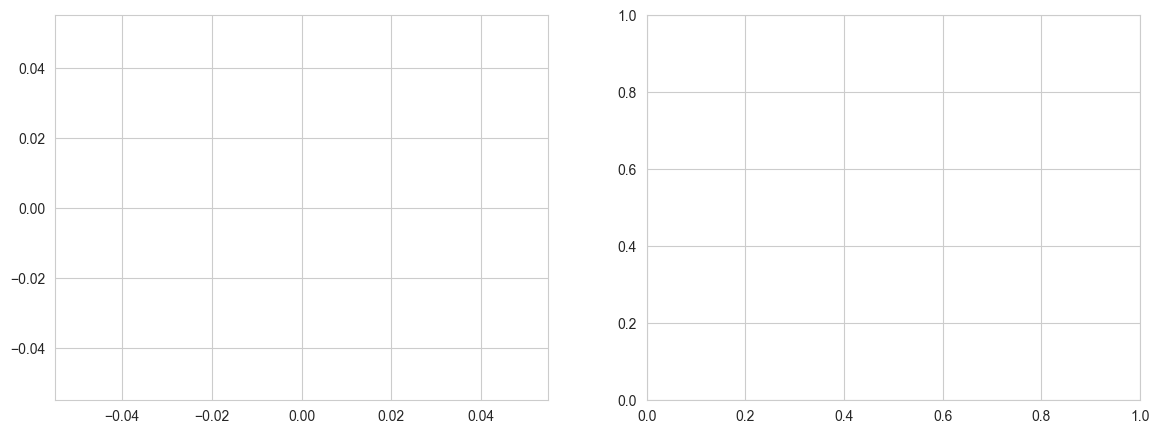

In [10]:
# Analyze freeze frame data structure in detail
if isinstance(sample_freeze_frame, list) and len(sample_freeze_frame) > 0:
    # Extract event information
    event_info = []
    
    for event in sample_freeze_frame[:100]:  # Analyze first 100 events
        info = {
            'has_tracking': 'freeze_frame' in event or 'tracking_data' in event,
            'event_type': event.get('type', {}).get('name', 'Unknown'),
            'has_location': 'location' in event,
            'has_freeze_frame': 'freeze_frame' in event
        }
        
        # Check for tracking data fields
        if 'freeze_frame' in event and event['freeze_frame']:
            info['num_players_in_frame'] = len(event['freeze_frame'])
        else:
            info['num_players_in_frame'] = 0
            
        event_info.append(info)
    
    event_info_df = pd.DataFrame(event_info)
    
    print("\n" + "="*70)
    print("FREEZE FRAME DATA ANALYSIS (First 100 events)")
    print("="*70)
    
    print(f"\nEvents with tracking data: {event_info_df['has_tracking'].sum()}/{len(event_info_df)}")
    print(f"Events with freeze frame: {event_info_df['has_freeze_frame'].sum()}/{len(event_info_df)}")
    print(f"Events with location: {event_info_df['has_location'].sum()}/{len(event_info_df)}")
    
    print(f"\nEvent types with freeze frames:")
    events_with_ff = event_info_df[event_info_df['has_freeze_frame']]
    print(events_with_ff['event_type'].value_counts().head(10))
    
    print(f"\nAverage players per freeze frame: {event_info_df['num_players_in_frame'].mean():.1f}")
    print(f"Max players in a frame: {event_info_df['num_players_in_frame'].max()}")
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Event type distribution with freeze frames
    events_with_ff['event_type'].value_counts().head(10).plot(kind='barh', ax=ax1)
    ax1.set_xlabel('Count')
    ax1.set_title('Top 10 Event Types with Freeze Frames', fontweight='bold')
    
    # Players per frame distribution
    ax2.hist(event_info_df[event_info_df['num_players_in_frame'] > 0]['num_players_in_frame'], 
             bins=20, edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Number of Players')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Players per Freeze Frame', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 5. Check Data Completeness Across Matches


FILE SIZE AND COMPLETENESS ANALYSIS

Freeze frame file sizes (MB):
count    376.000000
mean      11.189230
std        1.249319
min        7.957143
25%       10.353703
50%       11.228241
75%       12.034840
max       14.591569
Name: freeze_frame_size_mb, dtype: float64

Number of events with tracking data:
count     376.000000
mean     3309.215426
std       361.522697
min      2355.000000
25%      3069.000000
50%      3320.000000
75%      3554.250000
max      4287.000000
Name: num_events_in_ff, dtype: float64


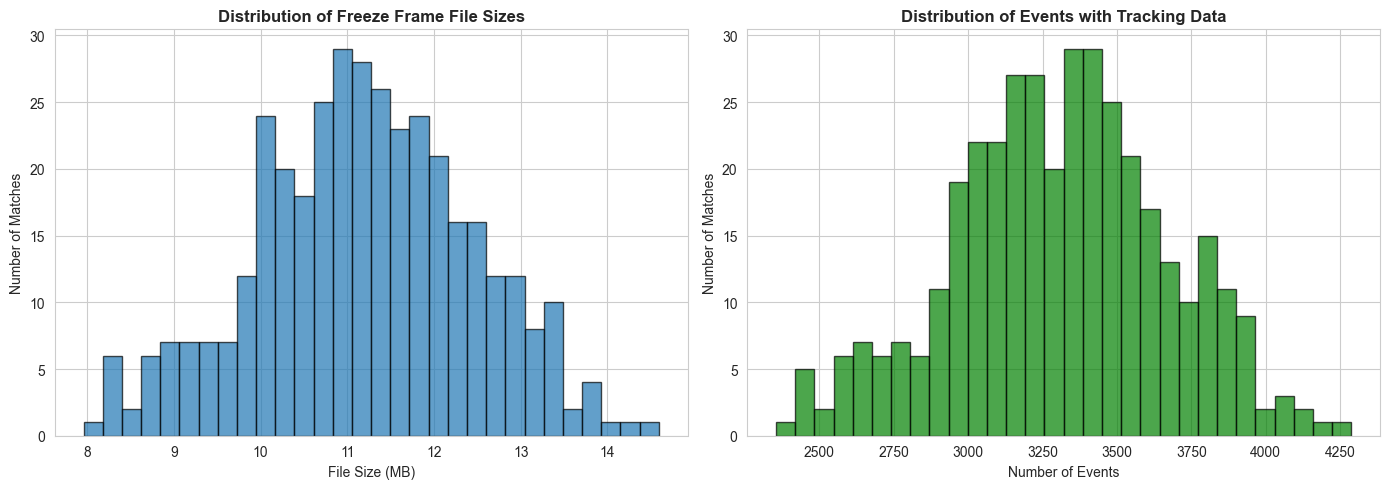

In [11]:
# Analyze file sizes and completeness
file_info = []

for idx, match in successful_df.iterrows():
    match_dir = match['match_dir']
    
    info = {
        'skc_match_id': match['skc_match_id'],
        'sb_match_id': match['sb_match_id']
    }
    
    # Check file existence and sizes
    freeze_frame_path = match_dir / 'freeze_frame_format.json'
    report_event_path = match_dir / 'report_by_event.csv'
    report_type_path = match_dir / 'report_by_event_type.csv'
    
    if freeze_frame_path.exists():
        info['freeze_frame_size_mb'] = freeze_frame_path.stat().st_size / (1024 * 1024)
        
        # Count events in freeze frame
        with open(freeze_frame_path, 'r') as f:
            ff_data = json.load(f)
            info['num_events_in_ff'] = len(ff_data) if isinstance(ff_data, list) else 0
    else:
        info['freeze_frame_size_mb'] = 0
        info['num_events_in_ff'] = 0
    
    if report_event_path.exists():
        info['report_event_size_kb'] = report_event_path.stat().st_size / 1024
    else:
        info['report_event_size_kb'] = 0
        
    if report_type_path.exists():
        info['report_type_size_kb'] = report_type_path.stat().st_size / 1024
    else:
        info['report_type_size_kb'] = 0
    
    file_info.append(info)

file_info_df = pd.DataFrame(file_info)

print("\n" + "="*70)
print("FILE SIZE AND COMPLETENESS ANALYSIS")
print("="*70)
print(f"\nFreeze frame file sizes (MB):")
print(file_info_df['freeze_frame_size_mb'].describe())

print(f"\nNumber of events with tracking data:")
print(file_info_df['num_events_in_ff'].describe())

# Plot file size distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(file_info_df['freeze_frame_size_mb'], bins=30, edgecolor='black', alpha=0.7)
ax1.set_xlabel('File Size (MB)')
ax1.set_ylabel('Number of Matches')
ax1.set_title('Distribution of Freeze Frame File Sizes', fontweight='bold')

ax2.hist(file_info_df['num_events_in_ff'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax2.set_xlabel('Number of Events')
ax2.set_ylabel('Number of Matches')
ax2.set_title('Distribution of Events with Tracking Data', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Summary and Key Findings

In [12]:
print("\n" + "="*70)
print("SUMMARY: MERGED DATASET QUALITY ASSESSMENT")
print("="*70)

print(f"\n1. DATA COVERAGE")
print(f"   - Successfully merged matches: {len(successful_df)}/380 (98.9%)")
print(f"   - Failed matches: {len(failed_matches)}/380 (1.1%)")
print(f"   - Total events across dataset: {total_events:,}")

print(f"\n2. SYNCHRONIZATION QUALITY")
print(f"   - Overall event-tracking match rate: {overall_match_rate:.2f}%")
print(f"   - Average events per match: {total_events/len(successful_df):.0f}")
print(f"   - Average matched events per match: {total_matched/len(successful_df):.0f}")
print(f"   - Mean match rate per match: {match_quality_df['match_rate'].mean():.2f}%")
print(f"   - Median match rate per match: {match_quality_df['match_rate'].median():.2f}%")

print(f"\n3. EVENT TYPE COVERAGE")
print(f"   - Unique event types: {combined_reports['statsbomb_event_type'].nunique()}")
print(f"   - Event types with >80% match rate: {len(event_summary[event_summary['match_rate_%'] > 80])}")
print(f"   - Event types with <50% match rate: {len(event_summary[event_summary['match_rate_%'] < 50])}")

print(f"\n4. BEST MATCHED EVENT TYPES (Top 5):")
best_matched = event_summary[event_summary['nb_events'] > 1000].nlargest(5, 'match_rate_%')
for idx, (event_type, row) in enumerate(best_matched.iterrows(), 1):
    print(f"   {idx}. {event_type}: {row['match_rate_%']:.1f}% ({int(row['nb_events'])} events)")

print(f"\n5. DATA COMPLETENESS")
print(f"   - Average freeze frame file size: {file_info_df['freeze_frame_size_mb'].mean():.2f} MB")
print(f"   - Average events with tracking: {file_info_df['num_events_in_ff'].mean():.0f}")
print(f"   - Min events per match: {file_info_df['num_events_in_ff'].min():.0f}")
print(f"   - Max events per match: {file_info_df['num_events_in_ff'].max():.0f}")

print(f"\n" + "="*70)
print("CONCLUSION: Merge quality is good. Dataset ready for analysis!")
print("="*70)


SUMMARY: MERGED DATASET QUALITY ASSESSMENT

1. DATA COVERAGE
   - Successfully merged matches: 376/380 (98.9%)
   - Failed matches: 4/380 (1.1%)
   - Total events across dataset: 1,244,341

2. SYNCHRONIZATION QUALITY
   - Overall event-tracking match rate: 84.05%
   - Average events per match: 3309
   - Average matched events per match: 2781
   - Mean match rate per match: 83.90%
   - Median match rate per match: 86.88%

3. EVENT TYPE COVERAGE
   - Unique event types: 33
   - Event types with >80% match rate: 17
   - Event types with <50% match rate: 12

4. BEST MATCHED EVENT TYPES (Top 5):
   1. Dribble: 91.5% (8205 events)
   2. Carry: 91.1% (268575 events)
   3. 50/50: 89.5% (2491 events)
   4. Ball Recovery: 89.5% (35482 events)
   5. Dribbled Past: 89.4% (4461 events)

5. DATA COMPLETENESS
   - Average freeze frame file size: 11.19 MB
   - Average events with tracking: 3309
   - Min events per match: 2355
   - Max events per match: 4287

CONCLUSION: Merge quality is good. Dataset

## 7. Export Summary Statistics

In [13]:
# Save summary statistics for reference
output_path = Path('data/eda_summary')
output_path.mkdir(exist_ok=True)

# Save successful matches list
successful_df.to_csv(output_path / 'successful_matches.csv', index=False)
print(f"✓ Saved successful matches list to {output_path / 'successful_matches.csv'}")

# Save match quality metrics
match_quality_df.to_csv(output_path / 'match_quality_metrics.csv', index=False)
print(f"✓ Saved match quality metrics to {output_path / 'match_quality_metrics.csv'}")

# Save event type summary
event_summary.to_csv(output_path / 'event_type_summary.csv')
print(f"✓ Saved event type summary to {output_path / 'event_type_summary.csv'}")

# Save file info
file_info_df.to_csv(output_path / 'file_completeness.csv', index=False)
print(f"✓ Saved file completeness info to {output_path / 'file_completeness.csv'}")

print(f"\n✓ All summary statistics exported to {output_path}/")

✓ Saved successful matches list to data\eda_summary\successful_matches.csv
✓ Saved match quality metrics to data\eda_summary\match_quality_metrics.csv
✓ Saved event type summary to data\eda_summary\event_type_summary.csv
✓ Saved file completeness info to data\eda_summary\file_completeness.csv

✓ All summary statistics exported to data\eda_summary/


## 8. Examine Merged Data Structure and Columns

In [14]:
# Load a sample freeze frame file and convert to DataFrame
sample_match = successful_df.iloc[0]
sample_freeze_frame_path = sample_match['match_dir'] / 'freeze_frame_format.json'

print(f"Loading merged data from match: {sample_match['skc_match_id']}")
print(f"StatsBomb Match ID: {sample_match['sb_match_id']}")

with open(sample_freeze_frame_path, 'r') as f:
    merged_data = json.load(f)

# Convert to DataFrame for easier viewing
if isinstance(merged_data, list):
    merged_df = pd.json_normalize(merged_data)
    
    print(f"\n{'='*70}")
    print("MERGED DATA STRUCTURE")
    print(f"{'='*70}")
    print(f"\nTotal events in file: {len(merged_df)}")
    print(f"Total columns: {len(merged_df.columns)}")
    
    print(f"\n{'='*70}")
    print("ALL COLUMNS IN MERGED DATA")
    print(f"{'='*70}")
    
    # Group columns by category for better readability
    event_cols = [col for col in merged_df.columns if not col.startswith('freeze_frame')]
    tracking_cols = [col for col in merged_df.columns if col.startswith('freeze_frame')]
    
    print(f"\n--- EVENT DATA COLUMNS ({len(event_cols)} columns) ---")
    for i, col in enumerate(event_cols[:50], 1):  # Show first 50
        print(f"  {i:2d}. {col}")
    if len(event_cols) > 50:
        print(f"  ... and {len(event_cols) - 50} more event columns")
    
    print(f"\n--- TRACKING DATA COLUMNS ({len(tracking_cols)} columns) ---")
    for i, col in enumerate(tracking_cols[:20], 1):  # Show first 20
        print(f"  {i:2d}. {col}")
    if len(tracking_cols) > 20:
        print(f"  ... and {len(tracking_cols) - 20} more tracking columns")
    
    print(f"\n{'='*70}")
    print("SAMPLE DATA - FIRST 3 EVENTS")
    print(f"{'='*70}")
    
    # Display key columns for first 3 events
    key_columns = ['id', 'index', 'period', 'timestamp', 'type.name', 
                   'possession_team.name', 'player.name', 'position.name',
                   'location', 'freeze_frame']
    
    # Filter to columns that exist
    display_cols = [col for col in key_columns if col in merged_df.columns]
    
    print("\nKey event information:")
    print(merged_df[display_cols].head(3).to_string())
    
    # Check if freeze_frame column exists and show its structure
    if 'freeze_frame' in merged_df.columns:
        print(f"\n{'='*70}")
        print("FREEZE FRAME DATA SAMPLE")
        print(f"{'='*70}")
        
        # Find an event with freeze frame data
        ff_events = merged_df[merged_df['freeze_frame'].notna()]
        if len(ff_events) > 0:
            sample_ff = ff_events.iloc[0]['freeze_frame']
            print(f"\nNumber of events with freeze frame data: {len(ff_events)}/{len(merged_df)}")
            print(f"\nSample freeze frame structure (first event with tracking):")
            print(f"  Type: {type(sample_ff)}")
            if isinstance(sample_ff, list) and len(sample_ff) > 0:
                print(f"  Number of players tracked: {len(sample_ff)}")
                print(f"\n  First player in freeze frame:")
                print(f"  {sample_ff[0]}")
        else:
            print("\nNo freeze frame data found in this sample")
    
else:
    print("Merged data is not in expected list format")

Loading merged data from match: 1410827
StatsBomb Match ID: 3925227

MERGED DATA STRUCTURE

Total events in file: 3639
Total columns: 28

ALL COLUMNS IN MERGED DATA

--- EVENT DATA COLUMNS (28 columns) ---
   1. frame
   2. timestamp
   3. period
   4. player_data
   5. statsbomb_event_id
   6. statsbomb_event_type
   7. player_id
   8. statsbomb_player_id
   9. team_id
  10. statsbomb_team_id
  11. is_matched
  12. is_player_detected
  13. projected_statsbomb_event_x
  14. projected_statsbomb_event_y
  15. ball_data.x
  16. ball_data.y
  17. ball_data.z
  18. ball_data.is_detected
  19. possession.player_id
  20. possession.group
  21. image_corners_projection.x_top_left
  22. image_corners_projection.y_top_left
  23. image_corners_projection.x_bottom_left
  24. image_corners_projection.y_bottom_left
  25. image_corners_projection.x_bottom_right
  26. image_corners_projection.y_bottom_right
  27. image_corners_projection.x_top_right
  28. image_corners_projection.y_top_right

--- TRAC

In [15]:
# Display additional data type information
print(f"\n{'='*70}")
print("COLUMN DATA TYPES")
print(f"{'='*70}")

# Show data types for key columns
print("\nData types for key columns:")
if isinstance(merged_data, list):
    important_cols = ['id', 'index', 'period', 'timestamp', 'minute', 'second',
                     'type.name', 'possession', 'possession_team.id', 'possession_team.name',
                     'play_pattern.name', 'team.id', 'team.name', 'player.id', 'player.name',
                     'position.id', 'position.name', 'location', 'under_pressure', 
                     'duration', 'freeze_frame']
    
    existing_cols = [col for col in important_cols if col in merged_df.columns]
    
    for col in existing_cols:
        dtype = merged_df[col].dtype
        non_null = merged_df[col].notna().sum()
        null_count = merged_df[col].isna().sum()
        print(f"  {col:30s} | {str(dtype):15s} | Non-null: {non_null:5d} | Null: {null_count:5d}")

print(f"\n{'='*70}")
print("SAMPLE VALUES FROM DIFFERENT COLUMN TYPES")
print(f"{'='*70}")

# Show unique values for categorical columns
categorical_cols = ['type.name', 'play_pattern.name', 'position.name']
for col in categorical_cols:
    if col in merged_df.columns:
        print(f"\n{col}:")
        print(f"  Unique values: {merged_df[col].nunique()}")
        print(f"  Top 5 most common:")
        for idx, (val, count) in enumerate(merged_df[col].value_counts().head(5).items(), 1):
            print(f"    {idx}. {val}: {count} times")


COLUMN DATA TYPES

Data types for key columns:
  period                         | int64           | Non-null:  3639 | Null:     0
  timestamp                      | object          | Non-null:  3639 | Null:     0

SAMPLE VALUES FROM DIFFERENT COLUMN TYPES


In [16]:
# Compare with raw StatsBomb events to see what was added by merging
print(f"\n{'='*70}")
print("COMPARISON: MERGED vs RAW STATSBOMB DATA")
print(f"{'='*70}")

# Load raw StatsBomb events for the same match
with open('data/sb_data/sb_events.json', 'r', encoding='utf-8') as f:
    all_sb_events = json.load(f)

# Filter for this match
raw_events = [e for e in all_sb_events if e.get('match_id') == sample_match['sb_match_id']]
raw_df = pd.json_normalize(raw_events)

print(f"\nRaw StatsBomb events: {len(raw_df)} events, {len(raw_df.columns)} columns")
print(f"Merged data:          {len(merged_df)} events, {len(merged_df.columns)} columns")
print(f"\nColumns added by merging: {len(merged_df.columns) - len(raw_df.columns)}")

# Find which columns are new (were added by the merge)
raw_cols = set(raw_df.columns)
merged_cols = set(merged_df.columns)
new_cols = merged_cols - raw_cols

print(f"\nNew columns added during merge process:")
for i, col in enumerate(sorted(new_cols), 1):
    print(f"  {i:2d}. {col}")

print(f"\n{'='*70}")
print("CONCLUSION: Understanding the Merged Data")
print(f"{'='*70}")
print(f"""
The merged data combines:
1. All original StatsBomb event data (match_id, type, player, location, etc.)
2. Enriched freeze_frame field with SkillCorner tracking data
3. Synchronized tracking positions for players at each event timestamp

You can use this merged data to:
- Analyze player positions during specific events (passes, shots, etc.)
- Calculate spatial metrics (distances, angles, space control)
- Study tactical formations and movements
- Link event success/failure to spatial context
""")


COMPARISON: MERGED vs RAW STATSBOMB DATA

Raw StatsBomb events: 3639 events, 130 columns
Merged data:          3639 events, 28 columns

Columns added by merging: -102

New columns added during merge process:
   1. ball_data.is_detected
   2. ball_data.x
   3. ball_data.y
   4. ball_data.z
   5. frame
   6. image_corners_projection.x_bottom_left
   7. image_corners_projection.x_bottom_right
   8. image_corners_projection.x_top_left
   9. image_corners_projection.x_top_right
  10. image_corners_projection.y_bottom_left
  11. image_corners_projection.y_bottom_right
  12. image_corners_projection.y_top_left
  13. image_corners_projection.y_top_right
  14. is_matched
  15. is_player_detected
  16. player_data
  17. player_id
  18. possession.group
  19. possession.player_id
  20. projected_statsbomb_event_x
  21. projected_statsbomb_event_y
  22. statsbomb_event_id
  23. statsbomb_event_type
  24. statsbomb_player_id
  25. statsbomb_team_id
  26. team_id

CONCLUSION: Understanding the Merg